# **OUTLIER TECHNIQUES**
 * IQR
 * Percentile
 * Z-Score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create sample data
data = [1, 2, 2, 3, 4, 4, 4, 5, 5, 6, 6, 7, 8, 9, 100]


In [2]:
def custom_sort(arr):
    """Custom sorting function"""
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr


In [3]:
def custom_quartiles(data):
    """Calculate Q1 and Q3 manually"""
    sorted_data = custom_sort(data.copy())
    n = len(sorted_data)
    
    # Find Q1
    q1_pos = n//4
    q1 = sorted_data[q1_pos]
    
    # Find Q3
    q3_pos = (3*n)//4
    q3 = sorted_data[q3_pos]
    
    return q1, q3

In [4]:
def iqr_method(data):
    """IQR Method for outlier detection"""
    q1, q3 = custom_quartiles(data)
    iqr = q3 - q1
    
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    outliers = [x for x in data if x < lower_bound or x > upper_bound]
    clean_data = [x for x in data if x >= lower_bound and x <= upper_bound]
    
    return outliers, clean_data, (lower_bound, upper_bound)

In [5]:
def percentile_method(data, lower_percentile=1, upper_percentile=99):
    """Percentile Method for outlier detection"""
    sorted_data = custom_sort(data.copy())
    n = len(sorted_data)
    
    lower_idx = int((lower_percentile/100) * n)
    upper_idx = int((upper_percentile/100) * n)
    
    lower_bound = sorted_data[lower_idx]
    upper_bound = sorted_data[upper_idx]
    
    outliers = [x for x in data if x < lower_bound or x > upper_bound]
    clean_data = [x for x in data if x >= lower_bound and x <= upper_bound]
    
    return outliers, clean_data, (lower_bound, upper_bound)

In [6]:
def zscore_method(data, threshold=3):
    """Z-Score Method for outlier detection"""
    # Calculate mean
    mean = sum(data) / len(data)
    
    # Calculate standard deviation
    squared_diff_sum = sum((x - mean) ** 2 for x in data)
    std_dev = (squared_diff_sum / (len(data) - 1)) ** 0.5
    
    # Calculate z-scores
    z_scores = [(x - mean) / std_dev for x in data]
    
    # Identify outliers
    outliers = [data[i] for i in range(len(data)) if abs(z_scores[i]) > threshold]
    clean_data = [data[i] for i in range(len(data)) if abs(z_scores[i]) <= threshold]
    
    return outliers, clean_data, z_scores

In [7]:
# Test the methods
print("Original Data:", data)

Original Data: [1, 2, 2, 3, 4, 4, 4, 5, 5, 6, 6, 7, 8, 9, 100]


In [8]:
# IQR Method
outliers_iqr, clean_data_iqr, bounds_iqr = iqr_method(data)
print("\nIQR Method:")
print("Outliers:", outliers_iqr)
print("Clean Data:", clean_data_iqr)
print("Bounds (lower, upper):", bounds_iqr)



IQR Method:
Outliers: [100]
Clean Data: [1, 2, 2, 3, 4, 4, 4, 5, 5, 6, 6, 7, 8, 9]
Bounds (lower, upper): (-3.0, 13.0)


In [9]:
# Percentile Method
outliers_perc, clean_data_perc, bounds_perc = percentile_method(data)
print("\nPercentile Method:")
print("Outliers:", outliers_perc)
print("Clean Data:", clean_data_perc)
print("Bounds (lower, upper):", bounds_perc)


Percentile Method:
Outliers: []
Clean Data: [1, 2, 2, 3, 4, 4, 4, 5, 5, 6, 6, 7, 8, 9, 100]
Bounds (lower, upper): (1, 100)


In [10]:
# Z-Score Method
outliers_z, clean_data_z, z_scores = zscore_method(data)
print("\nZ-Score Method:")
print("Outliers:", outliers_z)
print("Clean Data:", clean_data_z)


Z-Score Method:
Outliers: [100]
Clean Data: [1, 2, 2, 3, 4, 4, 4, 5, 5, 6, 6, 7, 8, 9]


([], [])

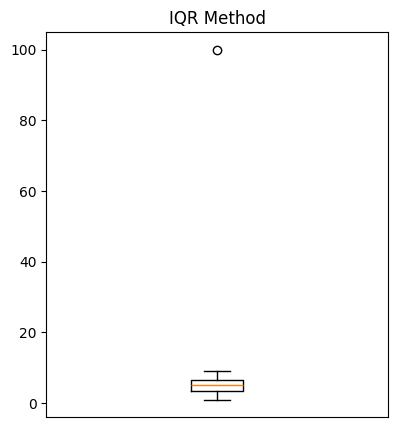

In [ ]:
# Visualization
plt.figure(figsize=(15, 5))

# IQR Plot
plt.subplot(131)
plt.boxplot(data)
plt.title('IQR Method')
plt.xticks([])
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Percentile Method')

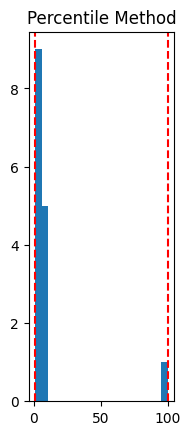

In [ ]:
# Percentile Plot
plt.subplot(132)
plt.hist(data, bins=20)
plt.axvline(bounds_perc[0], color='r', linestyle='--')
plt.axvline(bounds_perc[1], color='r', linestyle='--')
plt.title('Percentile Method')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Z-Score Method')

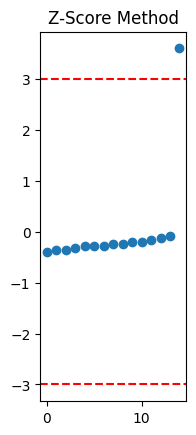

In [ ]:
# Z-Score Plot
plt.subplot(133)
plt.scatter(range(len(data)), z_scores)
plt.axhline(y=3, color='r', linestyle='--')
plt.axhline(y=-3, color='r', linestyle='--')
plt.title('Z-Score Method')
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>